# Detector de Idiomas - Pipeline completo
### Procesamiento de Lenguaje Natural
Este notebook cubre todo el pipeline:
1. Carga y exploración del corpus
2. Normalización
3. Extracción de características
4. Entrenamiento del modelo
5. Evaluación
6. Guardado del modelo

## Celda 1 - Importar librerías

In [1]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## Celda 2 - Cargar el corpus
Asegúrate de que el archivo CSV esté en la misma carpeta que este notebook.

In [2]:
# Cargar el dataset
df = pd.read_csv('Language Detection.csv')

# Ver las primeras filas
print('Primeras filas del dataset:')
print(df.head(10))

print(f'\nForma del dataset: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

Primeras filas del dataset:
                                                Text Language
0   Nature, in the broadest sense, is the natural...  English
1  "Nature" can refer to the phenomena of the phy...  English
2  The study of nature is a large, if not the onl...  English
3  Although humans are part of nature, human acti...  English
4  [1] The word nature is borrowed from the Old F...  English
5  [2] In ancient philosophy, natura is mostly us...  English
6  [3][4] \nThe concept of nature as a whole, the...  English
7  During the advent of modern scientific method ...  English
8  [5][6] With the Industrial revolution, nature ...  English
9  However, a vitalist vision of nature, closer t...  English

Forma del dataset: (10337, 2)
Columnas: ['Text', 'Language']


## Celda 3 - Exploración del corpus
Verificamos cuántos textos hay por idioma para revisar el equilibrio del corpus.

Cantidad de textos por idioma:
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


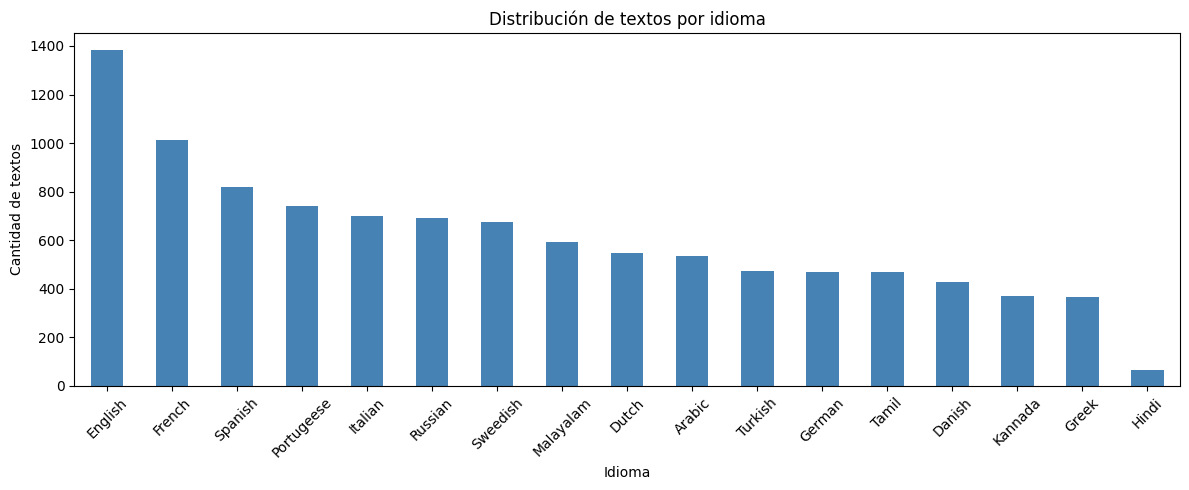

In [3]:
# Contar textos por idioma
print('Cantidad de textos por idioma:')
print(df['Language'].value_counts())

# Visualizar el balance del corpus
plt.figure(figsize=(12, 5))
df['Language'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución de textos por idioma')
plt.xlabel('Idioma')
plt.ylabel('Cantidad de textos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Celda 4 - Filtrar solo los idiomas que nos interesan
Trabajaremos con: Español, Inglés, Francés y Portugués.

In [4]:
# Seleccionar solo los 4 idiomas
idiomas_seleccionados = ['Spanish', 'English', 'French', 'Portugeese']

df_filtrado = df[df['Language'].isin(idiomas_seleccionados)].copy()

print(f'Textos totales antes del filtro: {len(df)}')
print(f'Textos totales después del filtro: {len(df_filtrado)}')
print(f'\nDistribución:')
print(df_filtrado['Language'].value_counts())

Textos totales antes del filtro: 10337
Textos totales después del filtro: 3957

Distribución:
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Name: count, dtype: int64


## Celda 5 - Normalización del texto
Limpiamos los textos pero conservamos las letras especiales (ñ, ç, è, ã) porque son clave para detectar el idioma.

In [5]:
def normalizar_texto(texto):
    # Convertir a minúsculas
    texto = texto.lower()
    
    # Eliminar números
    texto = re.sub(r'\d+', ' ', texto)
    
    # Eliminar caracteres especiales EXCEPTO letras con tilde y especiales de idiomas
    # Conservamos: a-z, espacios, á é í ó ú ñ ü ç à è ù â ê î ô û ã õ
    texto = re.sub(r'[^a-záéíóúñüçàèùâêîôûãõäöß\s]', ' ', texto)
    
    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto)
    
    # Eliminar espacios al inicio y al final
    texto = texto.strip()
    
    return texto

# Aplicar normalización
df_filtrado['Text_normalizado'] = df_filtrado['Text'].apply(normalizar_texto)

# Verificar resultados
print('Ejemplo de normalización:')
print(f'\nOriginal:    {df_filtrado["Text"].iloc[0]}')
print(f'Normalizado: {df_filtrado["Text_normalizado"].iloc[0]}')

Ejemplo de normalización:

Original:     Nature, in the broadest sense, is the natural, physical, material world or universe.
Normalizado: nature in the broadest sense is the natural physical material world or universe


## Celda 6 - Eliminar textos vacíos después de normalizar

In [6]:
# Eliminar filas donde el texto quedó vacío después de normalizar
df_filtrado = df_filtrado[df_filtrado['Text_normalizado'].str.len() > 5]

print(f'Textos después de limpiar vacíos: {len(df_filtrado)}')
print(df_filtrado['Language'].value_counts())

Textos después de limpiar vacíos: 3949
Language
English       1384
French        1013
Spanish        815
Portugeese     737
Name: count, dtype: int64


## Celda 7 - Dividir el corpus en entrenamiento y prueba
Usamos la división 80% entrenamiento y 20% prueba, tal como se vio en clase.

In [7]:
X = df_filtrado['Text_normalizado']
y = df_filtrado['Language']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantener proporciones de cada idioma
)

print(f'Textos de entrenamiento: {len(X_train)}')
print(f'Textos de prueba:        {len(X_test)}')
print(f'\nDistribución en entrenamiento:')
print(y_train.value_counts())

Textos de entrenamiento: 3159
Textos de prueba:        790

Distribución en entrenamiento:
Language
English       1107
French         810
Spanish        652
Portugeese     590
Name: count, dtype: int64


## Celda 8 - Extracción de características con TF-IDF
Usamos n-gramas de caracteres (analyzer='char') porque capturan mejor los patrones de cada idioma, como combinaciones de letras típicas.

In [8]:
# Vectorizador con n-gramas de caracteres
vectorizador = TfidfVectorizer(
    analyzer='char',       # Analizar caracteres, no palabras completas
    ngram_range=(2, 4),    # N-gramas de 2 a 4 caracteres
    max_features=50000,    # Máximo 50.000 características
    sublinear_tf=True      # Aplicar escala logarítmica a las frecuencias
)

# Aprender el vocabulario con los datos de entrenamiento
X_train_vec = vectorizador.fit_transform(X_train)

# Transformar los datos de prueba
X_test_vec = vectorizador.transform(X_test)

print(f'Forma de la matriz de entrenamiento: {X_train_vec.shape}')
print(f'Forma de la matriz de prueba:        {X_test_vec.shape}')

Forma de la matriz de entrenamiento: (3159, 36488)
Forma de la matriz de prueba:        (790, 36488)


## Celda 9 - Entrenar el modelo

In [9]:
# Crear y entrenar el modelo
modelo = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial'
)

modelo.fit(X_train_vec, y_train)

print('Modelo entrenado correctamente')

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

## Celda 10 - Evaluar el modelo

In [ ]:
# Predecir sobre los datos de prueba
y_pred = modelo.predict(X_test_vec)

# Exactitud general
accuracy = accuracy_score(y_test, y_pred)
print(f'Exactitud del modelo: {accuracy * 100:.2f}%')

# Reporte detallado por idioma
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred))

## Celda 11 - Matriz de confusión
Nos muestra en qué idiomas se equivoca el modelo.

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=idiomas_seleccionados)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=idiomas_seleccionados,
    yticklabels=idiomas_seleccionados
)
plt.title('Matriz de Confusión')
plt.ylabel('Idioma Real')
plt.xlabel('Idioma Predicho')
plt.tight_layout()
plt.show()

## Celda 12 - Probar el modelo con textos nuevos

In [ ]:
def detectar_idioma(texto):
    texto_normalizado = normalizar_texto(texto)
    texto_vec = vectorizador.transform([texto_normalizado])
    idioma = modelo.predict(texto_vec)[0]
    probabilidades = modelo.predict_proba(texto_vec)[0]
    confianza = max(probabilidades) * 100
    return idioma, confianza

# Pruebas
textos_prueba = [
    'El procesamiento del lenguaje natural es muy interesante',
    'Natural language processing is a fascinating field',
    'Le traitement du langage naturel est très intéressant',
    'O processamento de linguagem natural é muito interessante'
]

print('Resultados de detección:')
print('-' * 60)
for texto in textos_prueba:
    idioma, confianza = detectar_idioma(texto)
    print(f'Texto:    {texto[:50]}...')
    print(f'Idioma:   {idioma} ({confianza:.1f}% de confianza)')
    print('-' * 60)

## Celda 13 - Guardar el modelo y el vectorizador
Guardamos ambos archivos en la carpeta `modelo/` para usarlos en la aplicación Flask.

In [ ]:
import os

# Crear carpeta modelo si no existe
os.makedirs('../modelo', exist_ok=True)

# Guardar el modelo
joblib.dump(modelo, '../modelo/modelo_idiomas.pkl')

# Guardar el vectorizador
joblib.dump(vectorizador, '../modelo/vectorizador.pkl')

print('Modelo guardado en: ../modelo/modelo_idiomas.pkl')
print('Vectorizador guardado en: ../modelo/vectorizador.pkl')

## ¡Listo! 
El modelo y el vectorizador están guardados y listos para usarse en la aplicación Flask.

**Resumen del pipeline:**
1. ✅ Corpus cargado y explorado
2. ✅ Textos normalizados
3. ✅ Corpus dividido 80/20
4. ✅ Características extraídas con TF-IDF + n-gramas
5. ✅ Modelo entrenado
6. ✅ Modelo evaluado
7. ✅ Modelo guardado